## Loading the dataset

In [3]:
import pandas as pd
import matplotlib.pyplot as plt   
import seaborn as sns
import numpy as np

%matplotlib inline  

In [4]:
df = pd.read_csv('/Users/laracacador/Documents/Ironhack/Week_5/Day_1/amz_uk_price_prediction_dataset.csv')

## Exploration

In [5]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [6]:
df.dtypes

uid                    int64
asin                  object
title                 object
stars                float64
reviews                int64
price                float64
isBestSeller            bool
boughtInLastMonth      int64
category              object
dtype: object

## Part 1: Analyzing Best-Seller Trends Across Product Categories
### Objective: Understand the relationship between product categories and their best-seller status.

### 1. Crosstab Analysis:

In [7]:
# Generating a crosstab for 'category' and 'isBestSeller'

crosstab_result = pd.crosstab(df['category'], df['isBestSeller'])
crosstab_result

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [21]:
proportion_table = pd.crosstab(df['category'], df['isBestSeller']).value_counts(ascending=False)
proportion_table
#????????

False   True
246     4       3
247     1       3
254     0       3
249     0       3
245     5       3
               ..
2481    2       1
2615    16      1
2738    0       1
2766    15      1
835935  330     1
Name: count, Length: 276, dtype: int64

In [27]:
# Sorting by the proportion of True (best-sellers), highest first (descending order)
proportion_table = pd.crosstab(df['category'], df['isBestSeller'], normalize='index').sort_values(by=True, ascending=False)

proportion_table.head(10)

isBestSeller,False,True
category,,
Grocery,0.941865,0.058135
Smart Home Security & Lighting,0.942308,0.057692
Health & Personal Care,0.942314,0.057686
Mobile Phone Accessories,0.957529,0.042471
Power & Hand Tools,0.964661,0.035339
"Billiard, Snooker & Pool",0.967871,0.032129
Pet Supplies,0.969800,0.030200
Home Brewing & Wine Making,0.971545,0.028455
Wind Instruments,0.972000,0.028000


In [29]:
top10_categories = (proportion_table[True] * 100).head(10)
top10_categories

category
Grocery                           5.813467
Smart Home Security & Lighting    5.769231
Health & Personal Care            5.768628
Mobile Phone Accessories          4.247104
Power & Hand Tools                3.533895
Billiard, Snooker & Pool          3.212851
Pet Supplies                      3.020028
Home Brewing & Wine Making        2.845528
Wind Instruments                  2.800000
Mirrors                           2.800000
Name: True, dtype: float64

#### Conclusion:
##### Based on the previous lab, the univariate analysis of the same dataset, we saw that there were a lot of categories (296)
##### Here, for the proportion table, it makes sense to look only at the top 10 categories with the highest proportion of best-sellers
##### We can observe that 'Grocery', 'Smart Home Security & Lighting' and 'Health & Personal Care' have, each one, around ~5% of their products marked as best-sellers

### 2. Statistical Tests:

Performing a Chi-square test for 'isBestSeller' and 'category' to determine if they are independent.

In [22]:
from scipy.stats import chi2_contingency

chi2_statistic, chi2_p_value, _, expected_freq = chi2_contingency(crosstab_result)

chi2_statistic, chi2_p_value, expected_freq

(np.float64(36540.20270061387),
 np.float64(0.0),
 array([[2.47190130e+02, 8.09870149e-01],
        [4.05371878e+03, 1.32812173e+01],
        [2.49183599e+02, 8.16401360e-01],
        [1.69145827e+03, 5.54173243e+00],
        [2.53170536e+02, 8.29463782e-01],
        [8.50214439e+03, 2.78556144e+01],
        [1.06650580e+02, 3.49419782e-01],
        [2.57157474e+02, 8.42526204e-01],
        [9.51781673e+03, 3.11832664e+01],
        [1.50008526e+04, 4.91473619e+01],
        [9.32544700e+03, 3.05530045e+01],
        [2.38219520e+02, 7.80479700e-01],
        [3.22941944e+03, 1.05805616e+01],
        [9.44704859e+03, 3.09514084e+01],
        [6.68808779e+03, 2.19122125e+01],
        [5.26275760e+02, 1.72423967e+00],
        [1.90296531e+04, 6.23469391e+01],
        [2.77191835e+03, 9.08164873e+00],
        [2.53170536e+02, 8.29463782e-01],
        [4.04674164e+02, 1.32583581e+00],
        [1.92489346e+04, 6.30653723e+01],
        [3.10482764e+03, 1.01723609e+01],
        [2.04330551e+02, 6

####  np.float64(0.0) -> tells us that p-value 0.0 is smaller than 0.05 
#### it means that the null hypothesis is rejected and that there is a statistically significant association between the two variables
#### BUT the ""sample"" of this dataset has +2millions of rows so it will detect any association

In [32]:
from scipy.stats.contingency import association

# Computing the association between variables in 'crosstab_result' using the "cramer" method
association(crosstab_result, method="cramer")

0.1222829439760564

#### as expected, because Amazon's dataset has more than 2millions rows, and 296 categories, the cramer's v is very low (~0.12)
#### it means that the strength of the relationship between 'category' and 'isBestSeller' is weak, because it is close to zero (zero = no association), in other words, category have an effect on best-seller status, but it's not a strong predictor
#### So the cramer's v is undoubtedly a more useful test for this case

### 3. Visualizations:

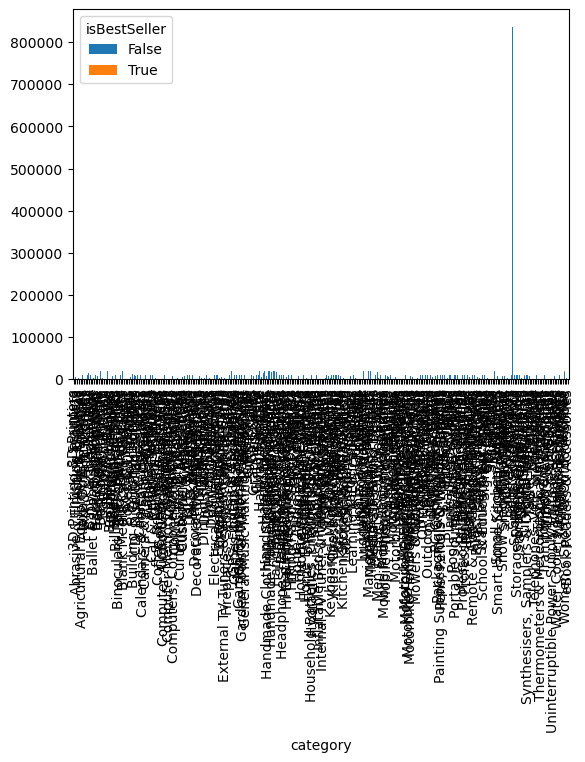

In [33]:
crosstab_result.plot(kind="bar", stacked=True);

In [34]:
#???????

In [43]:
## also it makes more sense to use the top10 of categories identified earlier:

Text(0, 0.5, 'Proportion')

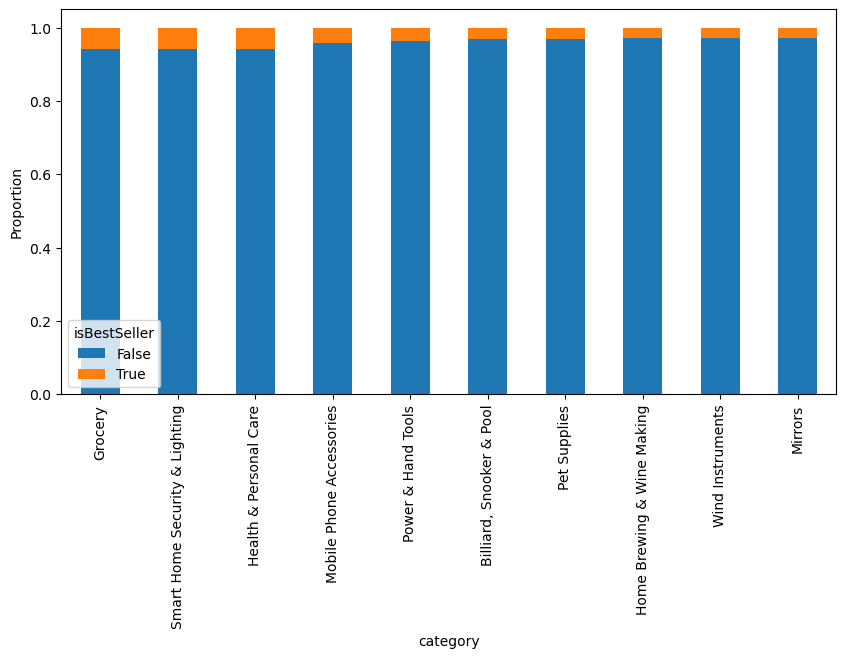

In [41]:
top10_prop_idx = proportion_table[True].sort_values(ascending=False).head(10).index

top10_prop = crosstab_result.loc[top10_prop_idx]
top10_prop = top10_prop.div(top10_prop.sum(axis=1), axis=0)

top10_prop.plot(kind="bar", stacked=True, figsize=(10,5));
plt.ylabel("Proportion")

Text(0, 0.5, 'Proportion of best-sellers')

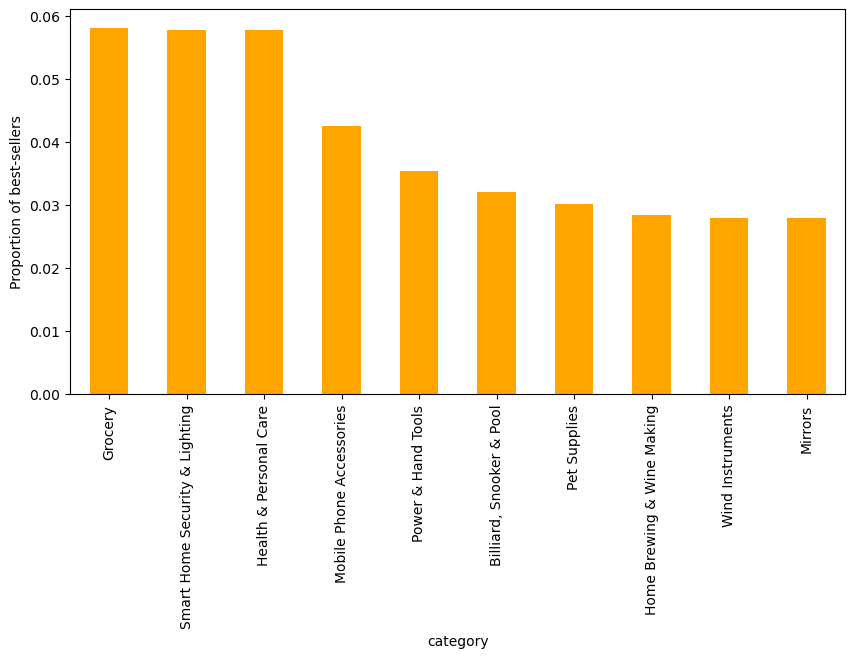

In [45]:
top10_prop[True].plot(kind="bar", color="orange", figsize=(10,5))
plt.ylabel("Proportion of best-sellers")

#### The first 'top10_prop' chart is consistente with the proportion table we did previously, with the same top 10 categories
#### In the second chart of 'top10_prop' (all in orange, using only the 'True' values) we can observe better the percentage of best-sellers (from ~5.8% (Grocery) down to ~2.8% (Mirrors)

---------

## Part 2: Exploring Product Prices and Ratings Across Categories and Brands
### Objective: Investigate how different product categories influence product prices.

In [46]:
# using Tukey's test for outliers:

def tukeys_test_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    # Define bounds for the outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify the outliers
    outliers = data[(data < lower_bound) | (data > upper_bound)]

    return outliers

In [47]:
data_series = df['price']  
outliers = tukeys_test_outliers(data_series)
print(outliers)

10         139.00
19         164.99
25         149.99
28         289.00
31         199.99
            ...  
2443619    166.99
2443627    152.58
2443638    108.77
2443641    166.99
2443643    158.99
Name: price, Length: 327688, dtype: float64


In [49]:
# Removing the rows from the dataframe
df_no_outliers = df.drop(outliers.index)
df_no_outliers

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers
...,...,...,...,...,...,...,...,...,...
2443646,2828589,B0CHSD7P2Q,"Motorbike Armour, Motorbike Clothing, Cycling ...",0.0,0,22.34,False,0,Motorbike Clothing
2443647,2828590,B0B7B8FNBQ,PROFIRST Waterproof Motorcycle 2 Piece Ladies ...,0.0,0,97.99,False,0,Motorbike Clothing
2443648,2828591,B0BD5FL5FB,Men’s Motorcycle Motorbike Biker Trousers Kevl...,0.0,0,52.99,False,0,Motorbike Clothing
2443649,2828592,B008OYLL4I,Texpeed Mens Motorcycle Motorbike Biker Trouse...,4.3,404,79.99,False,0,Motorbike Clothing


In [ ]:
## we can see that from +2.4milhões of rows, we have now decrease it to 2_115_963

In [57]:
print(f"The total number of rows is {len(df)}, the number of outliers is {len(outliers)}. Finally, the number of rows without outliers is {len(df_no_outliers)}")

The total number of rows is 2443651, the number of outliers is 327688. Finally, the number of rows without outliers is 2115963


### 1. Violin Plots:

In [62]:
top20_categories = df_no_outliers['category'].value_counts().head(20).index

In [69]:
df_top20 = df_no_outliers[df_no_outliers['category'].isin(top20_categories)]  #to filter the df to just keep the rows which category is on the top20

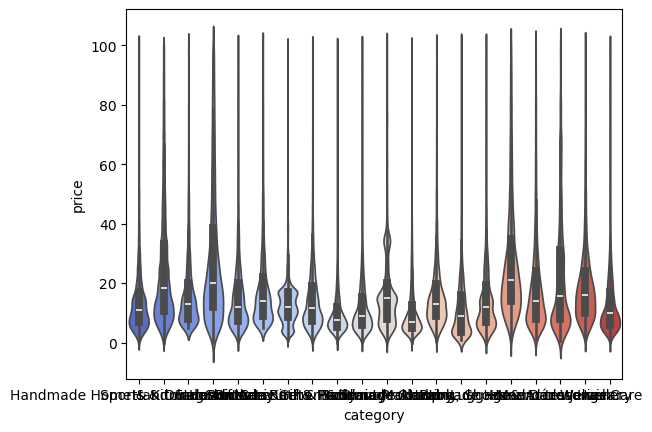

In [64]:
sns.violinplot(data=df_top20, x='category', y='price', palette="coolwarm", hue='category', legend=False);

In [ ]:
# from violins to malnourished cellos, let's correct it

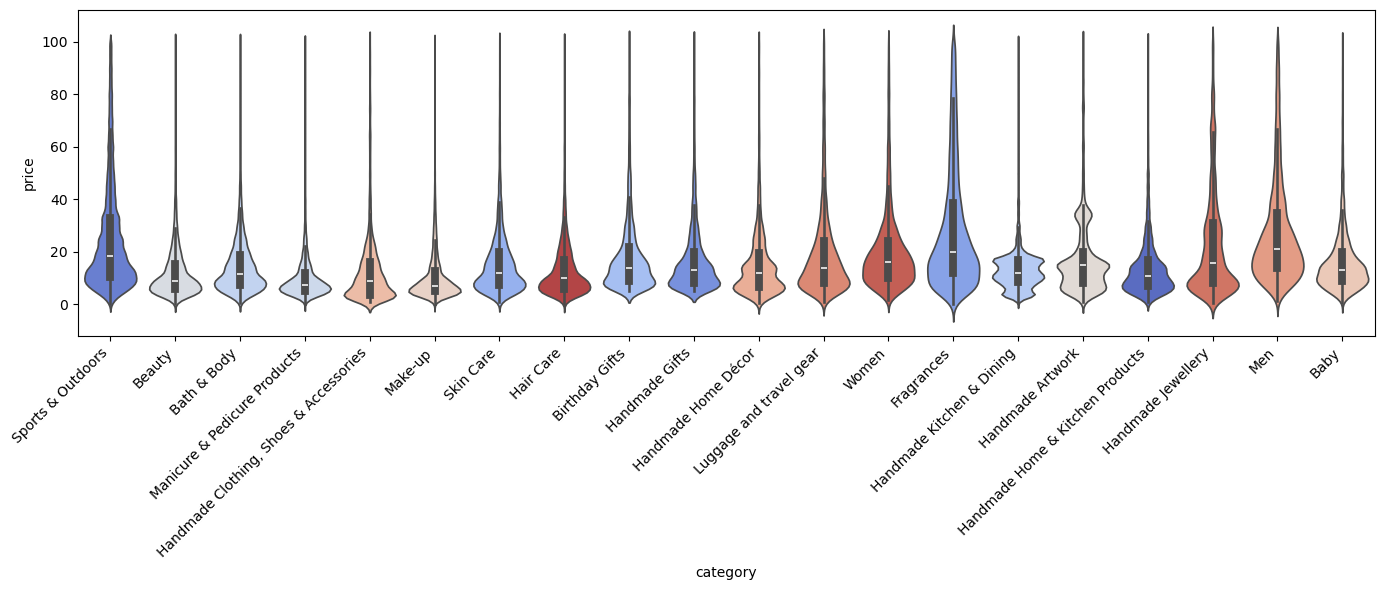

In [70]:
plt.figure(figsize=(14, 6))
sns.violinplot(data=df_top20, x='category', y='price', palette="coolwarm", hue='category', legend=False, order=top20_categories)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [72]:
median_by_category = df_no_outliers.groupby('category')['price'].median().sort_values(ascending=False)
median_by_category.head(10)

category
Desktop PCs               74.00
Boxing Shoes              69.79
Tablets                   69.00
Graphics Cards            68.54
Motherboards              67.92
Made in Italy Handmade    64.00
Digital Frames            63.90
Streaming Clients         62.68
Golf Shoes                62.39
Ski Helmets               61.33
Name: price, dtype: float64

#### Conclusion:
##### - Desktop PCs has the highest median price (74 libras)

### 2. Bar Charts:

In [75]:
mean_price = df_no_outliers['price'].mean()
mean_price

np.float64(23.408269686190163)

In [77]:
top10_categories = df_no_outliers['category'].value_counts().head(10).index
df_top10 = df_no_outliers[df_no_outliers['category'].isin(top10_categories)]

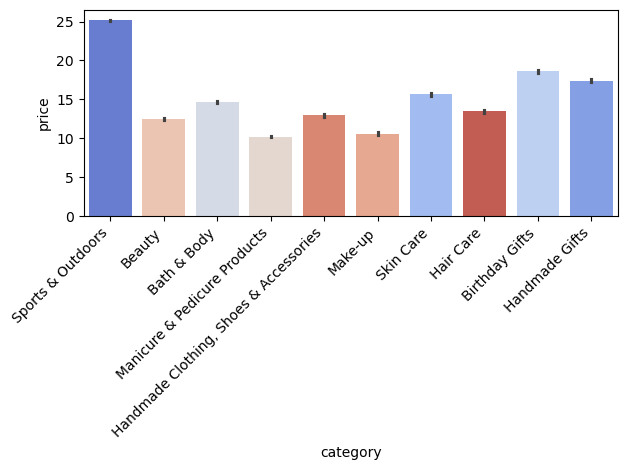

In [81]:
sns.barplot(data=df_top10, x='category', y='price', palette="coolwarm", hue='category', legend=False, order=top10_categories);
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [80]:
average_by_category = df_no_outliers.groupby('category')['price'].mean().sort_values(ascending=False)
average_by_category.head(10)

category
Motherboards         68.772432
Boxing Shoes         67.417803
Desktop PCs          66.915562
Tablets              66.552971
Graphics Cards       65.103509
Digital Frames       60.745129
Streaming Clients    60.241803
Hockey Shoes         60.094796
Computer Cases       58.339884
Skiing Poles         57.867770
Name: price, dtype: float64

#### The product category with the highest average price is the motherboards (~68 libras)

### 3. Box Plots:

In [82]:
top10_categories = df_no_outliers['category'].value_counts().head(10).index
df_top10 = df_no_outliers[df_no_outliers['category'].isin(top10_categories)]

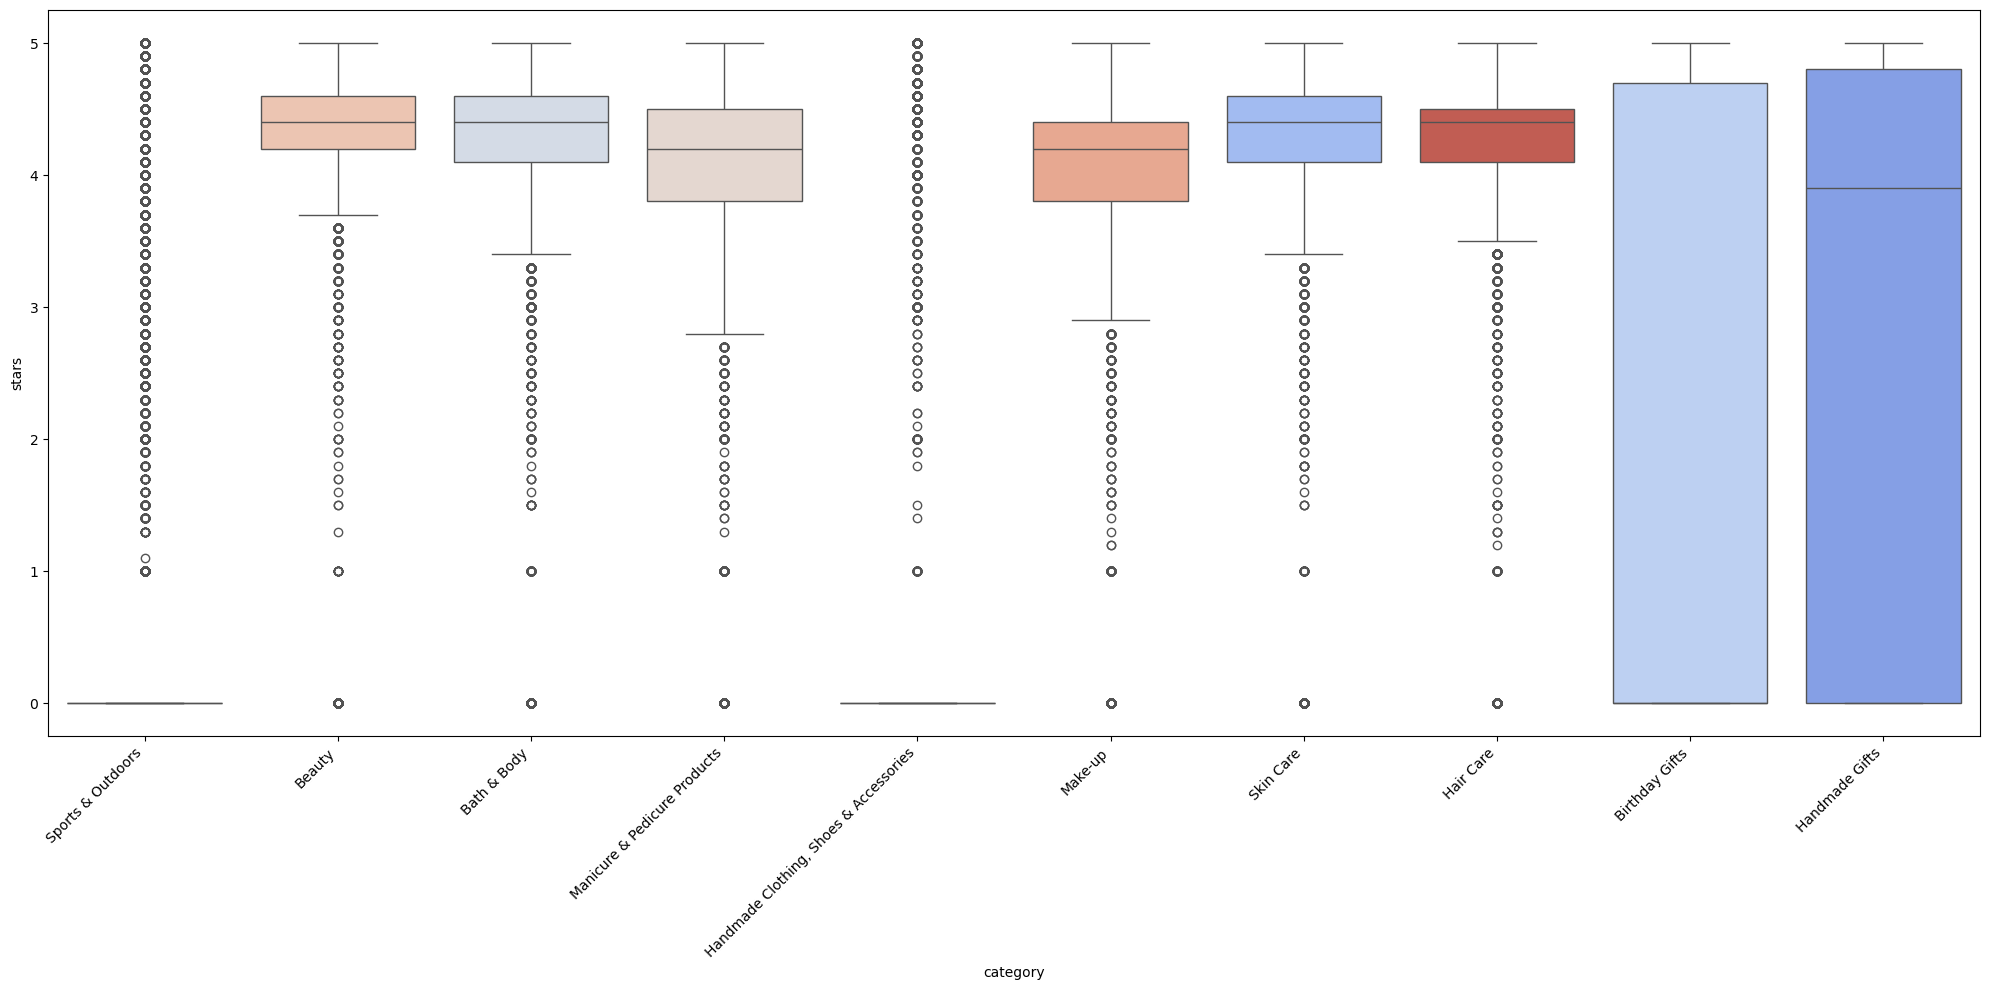

In [90]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=df_top10, x='category', y='stars', palette="coolwarm", hue='category', legend=False, order=top10_categories);
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [94]:
#???????

In [95]:
## 'Sports & Outdoors' box is basically flat at 0, bc a lot of its products are unrated, so those fake "0 stars" drag the whole box down -> long tail of outliers

df_top10_rated = df_top10[df_top10['stars'] > 0]   #as the previous lab, 0 stars means no reviews, so we have to filter them out

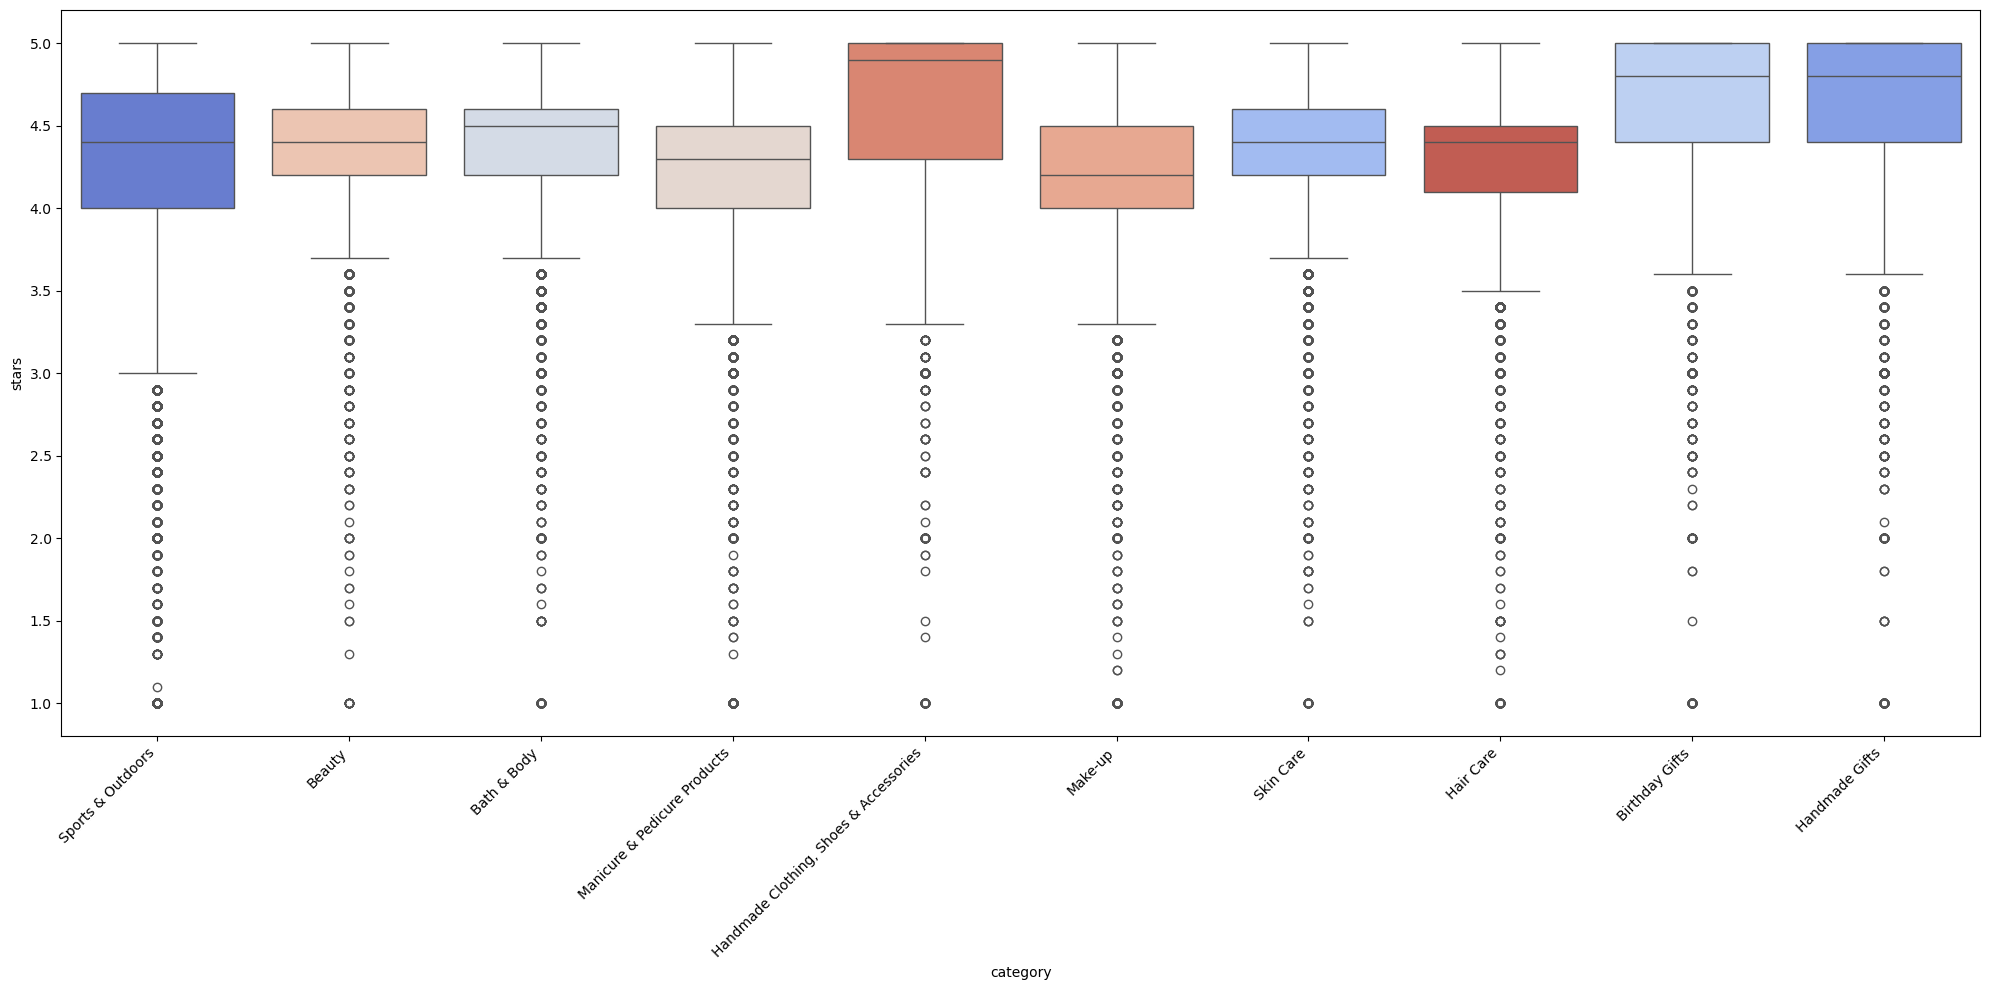

In [93]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=df_top10_rated, x='category', y='stars', palette="coolwarm", hue='category', legend=False, order=top10_categories)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [91]:
median_by_category = df_no_outliers.groupby('category')['stars'].mean().sort_values(ascending=False)
median_by_category.head(10)

category
Luxury Food & Drink                    4.544140
Grocery                                4.469414
Laptop Accessories                     4.449600
Health & Personal Care                 4.439549
Arts & Crafts                          4.432942
Office Paper Products                  4.430000
Customers' Most Loved                  4.404388
Water Coolers, Filters & Cartridges    4.394505
USB Hubs                               4.357430
Power & Hand Tools                     4.351565
Name: stars, dtype: float64

#### 'Luxury Food & Drink' and 'Grocery' have the highest median (~4.5)

-------

## Part 3: Investigating the Interplay Between Product Prices and Ratings
### Objective: Analyze how product ratings (stars) correlate with product prices.

### 1.Correlation Coefficients:

In [104]:
# Calculating the Pearson correlation coefficient between 'price' and 'stars' columns (both are numerical)
rated = df_no_outliers[df_no_outliers['stars'] > 0]

corr = rated['price'].corr(rated['stars'])
corr

np.float64(0.006744508067158014)

In [105]:
# Calculating the Spearman rank correlation between 'price' and 'stars'
corr = rated['price'].corr(rated['stars'], method='spearman')
corr

np.float64(0.024659617205380506)

In [ ]:
## above: non-rated reviews so also non-rated products were excluded, since it doesnt make sense and it is just noise.

#### based on pearson's coefficient and spearman's correlation, we can affirm:
##### -> pearson's coefficient is ~ 0.006, suggesting there is no linear relationship between reviews and product price

##### -> spearman's coefficient is ~ 0.025, suggesting a non-existent monotonic relationship either

#### We can conclude that product' price and reviews are unrelated, so regardless of price, reviews can be good or bad.

### Visualizations:

Text(0.5, 1.0, 'Price vs Rating')

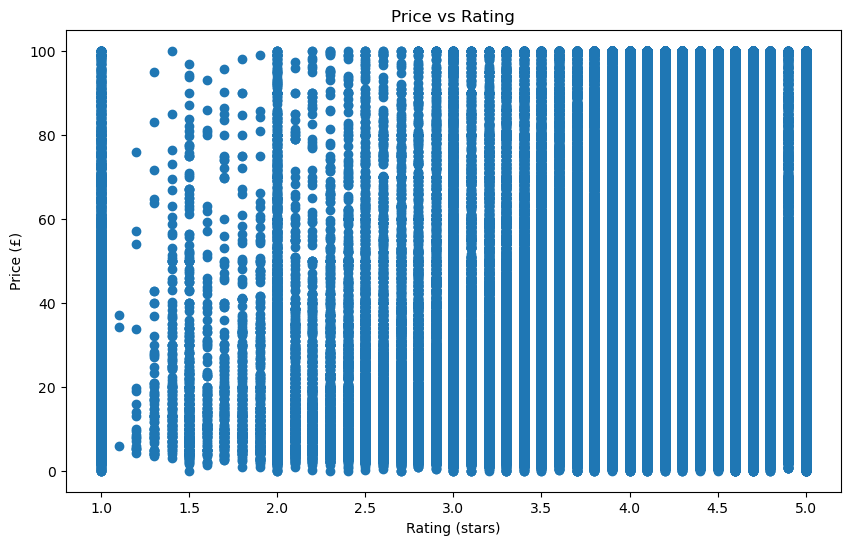

In [106]:
plt.figure(figsize=(10, 6))
plt.scatter(rated['stars'], rated['price'])
plt.xlabel('Rating (stars)')
plt.ylabel('Price (£)')
plt.title('Price vs Rating')

In [ ]:
#emoji crying rivers

#### a scatter plot is not a good way to visualize this because the dataset is too big 

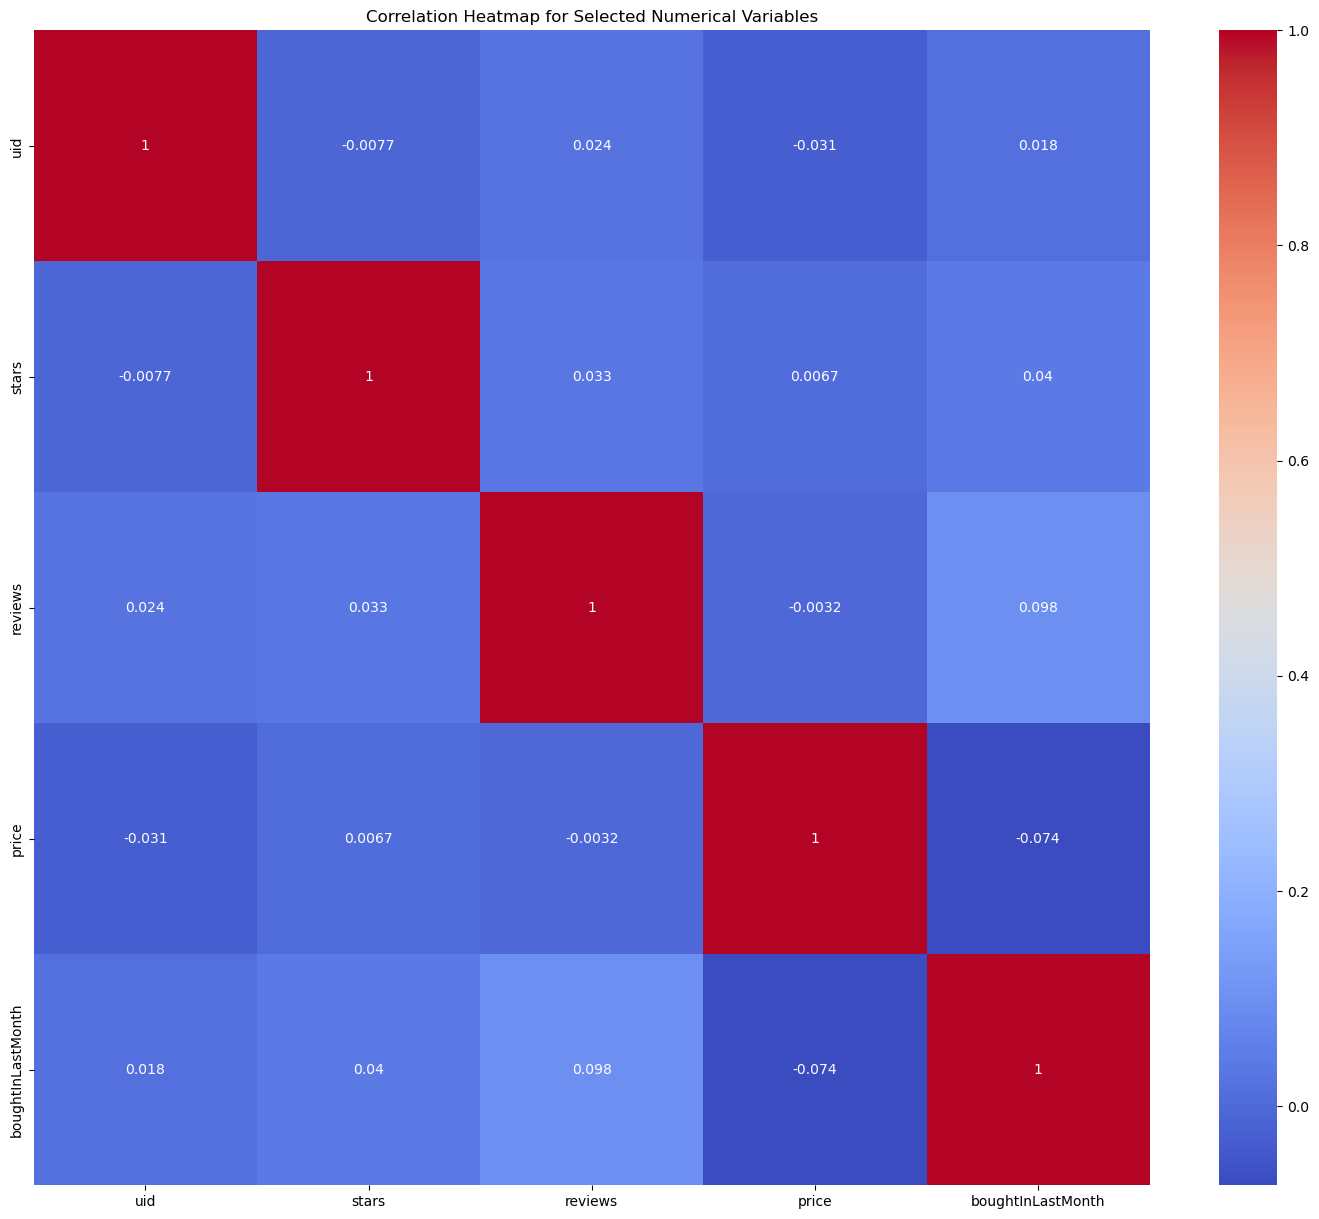

In [108]:
df_numerical = rated.select_dtypes(include='number')

correlation_matrix = df_numerical.corr()

plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap for Selected Numerical Variables")
plt.show()

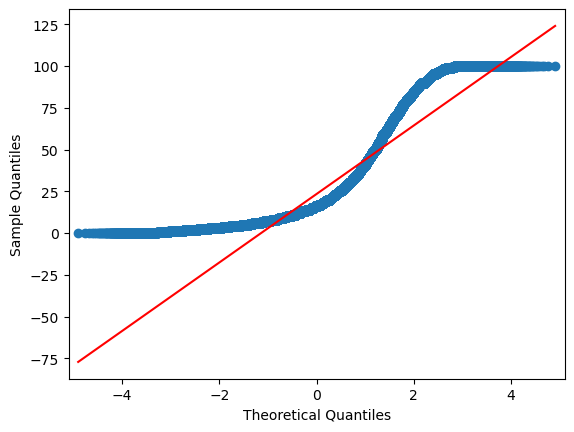

In [111]:
import statsmodels.api as sm

# Generating a QQ plot for 'price' to check if its distribution follows a normal distribution
sm.qqplot(df_no_outliers['price'], line='s');

#### The QQ plot has an S-shape: flat near 0, a rise in the middle, then flat again near £100
#### This makes sense because we already removed the outliers which makes the prices in a range between near 0 and £100
#### Both ends have a long tail